## Logistic Regression for Binary Classification

## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, confusion_matrix, 
                              roc_curve, auc, classification_report)

print("Libraries imported! ✅")

Libraries imported! ✅


In [5]:
df = pd.read_csv(r"C:\Users\MINHAJ\Downloads\Data Set For Task-20260408T161732Z-3-001\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2666, 20)

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

In [7]:
# Check which columns are text/categorical
print("Categorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

Categorical columns:
['State', 'International plan', 'Voice mail plan']


In [8]:
le = LabelEncoder()

# Encode all categorical (text) columns
categorical_cols = ['State', 'International plan', 'Voice mail plan', 'Churn']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    print(f"✅ Encoded: {col}")

print("\nEncoding done!")
df.head()

✅ Encoded: State
✅ Encoded: International plan
✅ Encoded: Voice mail plan
✅ Encoded: Churn

Encoding done!


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [9]:
# Target = Churn (will customer leave? 1=Yes, 0=No)
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nChurn value counts:")
print(y.value_counts())
print(f"\n{y.value_counts()[1]} customers churned out of {len(y)} total")

Features shape: (2666, 19)
Target shape: (2666,)

Churn value counts:
Churn
0    2278
1     388
Name: count, dtype: int64

388 customers churned out of 2666 total


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Done! ✅")

Training samples: 2132
Testing samples: 534
Done! ✅


### Training the model

In [11]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained! ✅")

# Show top features influencing churn
feature_importance = pd.DataFrame({
    'Feature': df.drop('Churn', axis=1).columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nTop factors causing churn (positive = more likely to churn):")
print(feature_importance.head(5).to_string(index=False))
print("\nTop factors reducing churn (negative = less likely to churn):")
print(feature_importance.tail(5).to_string(index=False))

Model trained! ✅

Top factors causing churn (positive = more likely to churn):
               Feature  Coefficient
    International plan     0.666242
Customer service calls     0.629263
     Total day minutes     0.372931
      Total day charge     0.372042
 Number vmail messages     0.328621

Top factors reducing churn (negative = less likely to churn):
          Feature  Coefficient
            State     0.000477
Total night calls    -0.035587
        Area code    -0.052993
 Total intl calls    -0.279873
  Voice mail plan    -0.764057


In [12]:
y_pred = model.predict(X_test)

print("=" * 45)
print("        MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"Accuracy:   {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision:  {precision_score(y_test, y_pred):.2%}")
print(f"Recall:     {recall_score(y_test, y_pred):.2%}")
print("=" * 45)
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Not Churn', 'Churn']))

        MODEL EVALUATION RESULTS
Accuracy:   85.96%
Precision:  56.25%
Recall:     22.78%

Full Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.88      0.97      0.92       455
       Churn       0.56      0.23      0.32        79

    accuracy                           0.86       534
   macro avg       0.72      0.60      0.62       534
weighted avg       0.83      0.86      0.83       534



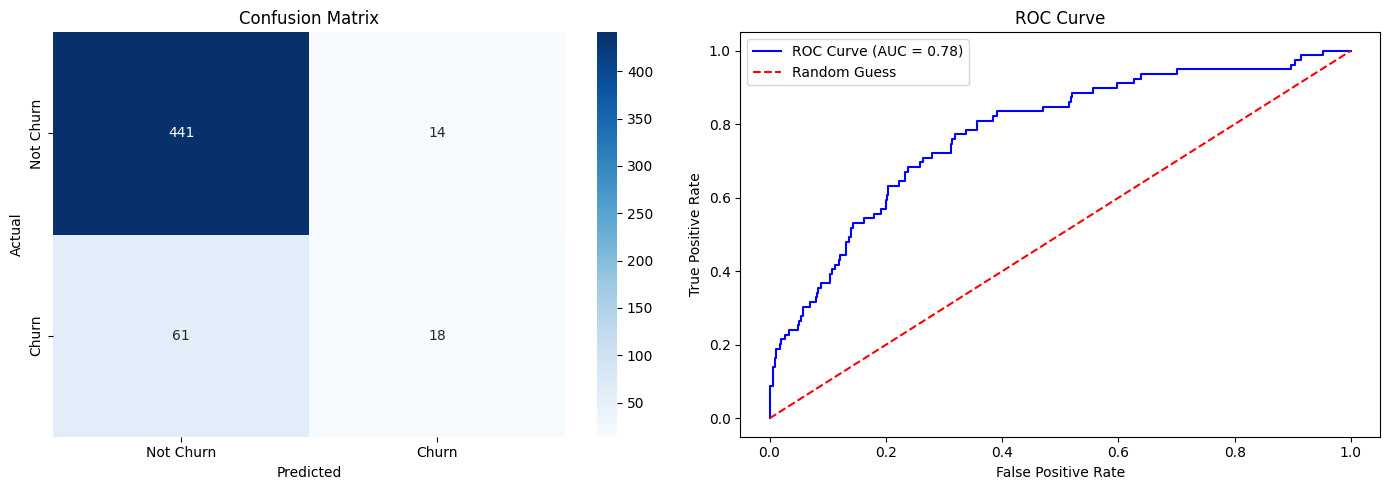

Plots saved! ✅


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- Plot 2: ROC Curve ---
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='blue', 
             label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Random Guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig("logistic_regression_results.png")
plt.show()
print("Plots saved! ✅")